# Phase 3 — NLP Processing: TF-IDF + BERT
## Fase 3 — Procesamiento NLP: TF-IDF + BERT


**EN:** Converts reading notes into numerical vectors using two complementary NLP techniques:
- **TF-IDF** — captures personal vocabulary: which words the reader uses most
- **BERT** — captures deep semantics: what those words *mean* in context

This phase is **incremental**: on subsequent runs it only processes new notes and merges  
them with existing embeddings, avoiding redundant BERT computation.

**ES:** Convierte las notas en vectores numéricos usando dos técnicas NLP complementarias:
- **TF-IDF** — captura el vocabulario personal: qué palabras usa más el lector
- **BERT** — captura la semántica profunda: qué *significan* esas palabras en contexto

Esta fase es **incremental**: en ejecuciones posteriores solo procesa notas nuevas y las combina  
con los embeddings existentes, evitando recalcular BERT innecesariamente.



## Step 1 — Install Dependencies / Instalar Dependencias


In [20]:
!pip install transformers -q
!pip install torch -q

print("Dependencies installed.")


Dependencies installed.


## Step 2 — Imports and Mount Drive / Imports y Montar Drive


In [21]:
import logging
import os
import pickle
import shutil

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from transformers import AutoTokenizer, AutoModel
import torch

from google.colab import drive

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger("phase_3")

drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/Colab Notebooks/PF_Ironhack/"

logger.info("Imports complete. Drive mounted.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3 — Load Notes via NotesManager / Cargar Notas con NotesManager

**EN:** We use `NotesManager` instead of loading the CSV directly for two reasons:
1. `get_notes_dataframe(only_unprocessed=True)` returns only notes not yet vectorized,  
   so BERT never runs on notes that already have embeddings.
2. `mark_as_processed()` updates the `processed` flag in `user_notes.csv` at the end,  
   so the system always knows which notes are new on the next run.

**ES:** Usamos `NotesManager` en lugar de cargar el CSV directamente por dos razones:
1. `get_notes_dataframe(only_unprocessed=True)` devuelve solo las notas aún no vectorizadas,  
   para que BERT nunca se ejecute sobre notas que ya tienen embeddings.
2. `mark_as_processed()` actualiza el flag `processed` en `user_notes.csv` al final,  
   para que el sistema sepa exactamente cuáles son notas nuevas en la siguiente ejecución.


In [22]:
shutil.copy(os.path.join(DRIVE_PATH, "notes_manager.py"), "/content/notes_manager.py")

from notes_manager import NotesManager

nm     = NotesManager(drive_path=DRIVE_PATH)
df_all = nm.get_notes_dataframe()                       # all notes — defines final matrix order
df_new = nm.get_notes_dataframe(only_unprocessed=True)  # only unprocessed — BERT input

print(f"Total notes      : {len(df_all)}")
print(f"Unprocessed notes: {len(df_new)}")

if len(df_new) == 0:
    print()
    print("No new notes to process. All notes are already vectorized.")
    print("Load existing .pkl files if you need the embeddings.")


Total notes      : 50
Unprocessed notes: 50


## Step 4 — Check Existing Artifacts / Verificar Artefactos Existentes

**EN:** Before processing, we check whether embeddings from a previous run already exist in Drive.
- **First run:** no `.pkl` files exist → process all notes from scratch.
- **Subsequent runs:** `.pkl` files exist → process only new notes, then merge.

**ES:** Antes de procesar, verificamos si ya existen embeddings de una ejecución anterior en Drive.
- **Primera ejecución:** no existen `.pkl` → procesar todas las notas desde cero.
- **Ejecuciones siguientes:** existen `.pkl` → procesar solo notas nuevas y combinar.


In [23]:
def load_pickle(filename: str, drive_path: str):
    """
    Loads a pickle file from Drive.
    Returns None if the file does not exist — used to detect first run.
    Unlike other phases, this does NOT raise FileNotFoundError.
    """
    filepath = os.path.join(drive_path, filename)
    if not os.path.exists(filepath):
        return None
    with open(filepath, 'rb') as f:
        return pickle.load(f)


bert_existing  = load_pickle('bert_embeddings.pkl', DRIVE_PATH)

is_first_run = bert_existing is None

if is_first_run:
    print("First run detected — no existing embeddings found.")
    print("All notes will be processed.")
else:
    print("Existing embeddings found.")
    print(f"  BERT   : {bert_existing.shape}")
    print(f"  New notes to add: {len(df_new)}")


First run detected — no existing embeddings found.
All notes will be processed.


## Step 5 — Text Preprocessing / Preprocesamiento de Texto

**EN:** Two separate cleaning pipelines, one per NLP technique:
- **TF-IDF branch** — aggressive normalization: lowercase, remove punctuation, collapse spaces.
- **BERT branch** — minimal cleaning: whitespace normalization only.  
  Transformer models perform better with natural text including punctuation and casing.

A third column `note_enriched` appends tags to the cleaned note to strengthen the TF-IDF vocabulary signal.

**Incremental logic / Lógica incremental:**
- **First run:** apply cleaning to all notes in `df_all`.
- **Subsequent runs:** load already-cleaned text from `user_notes_processed.csv` for existing notes;  
  apply cleaning only to new notes in `df_new`; then merge both into `df_all`.  
  This avoids recomputing text transformations on notes that were already processed.

**ES:** Dos pipelines de limpieza, uno por técnica NLP.  
En ejecuciones posteriores, las notas antiguas ya tienen el texto limpio guardado en  
`user_notes_processed.csv` — solo limpiamos las notas nuevas y combinamos ambos DataFrames.


In [24]:
def clean_for_tfidf(text: str) -> str:
    """Lowercase, remove punctuation, collapse whitespace."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def clean_for_bert(text: str) -> str:
    """Normalize whitespace only — BERT expects natural language input."""
    return re.sub(r'\s+', ' ', text).strip()


def combine_note_and_tags(row: pd.Series) -> str:
    """Append tags to the TF-IDF-cleaned note to enrich vocabulary signal."""
    tags = str(row['tags']) if pd.notna(row['tags']) else ''
    tags_clean = re.sub(r'\s+', ' ', tags.replace(',', ' ').replace('-', ' ')).strip()
    return row['note_clean_tfidf'] + ' ' + tags_clean


def apply_preprocessing(df: pd.DataFrame) -> pd.DataFrame:
    """Applies all three cleaning pipelines to a DataFrame of notes."""
    df = df.copy()
    df['note_clean_tfidf'] = df['note_text'].apply(clean_for_tfidf)
    df['note_clean_bert']  = df['note_text'].apply(clean_for_bert)
    df['note_enriched']    = df.apply(combine_note_and_tags, axis=1)
    return df


processed_csv_path = os.path.join(DRIVE_PATH, 'user_notes_processed.csv')

if is_first_run:
    df_all = apply_preprocessing(df_all)
    # Sync df_new with the cleaned columns now present in df_all
    df_new = df_all[df_all['note_id'].isin(df_new['note_id'])].copy()
    logger.info("First run. Preprocessing applied to all %d notes.", len(df_all))

else:
    # Subsequent run: load already-cleaned notes from the previous run's output
    df_processed = pd.read_csv(processed_csv_path)

    if len(df_new) > 0:
        # Clean only the new notes, then merge with the already-processed ones
        df_new = apply_preprocessing(df_new)
        df_all = pd.concat([df_processed, df_new], ignore_index=True)
        logger.info(
            "Incremental run. Loaded %d existing notes, cleaned %d new notes.",
            len(df_processed), len(df_new)
        )
    else:
        # No new notes at all — use the processed CSV as-is
        df_all = df_processed
        logger.info("No new notes. Using existing processed CSV (%d notes).", len(df_all))

print()
print("Example — Book 1:")
print(f"  Original : {df_all['note_text'].iloc[0][:100]}...")
print(f"  TF-IDF   : {df_all['note_clean_tfidf'].iloc[0][:100]}...")
print(f"  Enriched : {df_all['note_enriched'].iloc[0][:100]}...")



Example — Book 1:
  Original : A deeply poetic and immersive narrative. Kvothe is a complex and contradictory character, I loved an...
  TF-IDF   : a deeply poetic and immersive narrative kvothe is a complex and contradictory character i loved and ...
  Enriched : a deeply poetic and immersive narrative kvothe is a complex and contradictory character i loved and ...


## Step 6 — TF-IDF Vectorization / Vectorización TF-IDF

**EN:** TF-IDF is always re-fitted on the full corpus because its vocabulary  
is built from all notes together — adding new notes changes term frequencies across the collection.  

**ES:** TF-IDF siempre se re-entrena sobre el corpus completo porque su vocabulario  
se construye a partir de todas las notas juntas — añadir notas nuevas cambia las frecuencias.  

| Parameter | Value | Reason |
|-----------|-------|--------|
| `max_features` | 500 | Vocabulary cap — sufficient for ~40 short notes |
| `ngram_range` | (1, 2) | Single words and two-word phrases (e.g. "moral conflict") |
| `stop_words` | english | Removes function words: "the", "is", "a" |
| `min_df` | 1 | Include all terms, even those appearing once |


In [25]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=1
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_all['note_enriched'])
tfidf_array  = tfidf_matrix.toarray()

logger.info("TF-IDF complete. Shape: %s", str(tfidf_array.shape))
print(f"TF-IDF matrix: {tfidf_array.shape[0]} notes x {tfidf_array.shape[1]} features")
print()

feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf    = tfidf_array.mean(axis=0)
top_idx       = mean_tfidf.argsort()[::-1][:20]

print("Top 20 vocabulary terms by mean TF-IDF weight:")
print("-" * 45)
for idx in top_idx:
    print(f"  {feature_names[idx]:<28} {mean_tfidf[idx]:.4f}")


TF-IDF matrix: 50 notes x 500 features

Top 20 vocabulary terms by mean TF-IDF weight:
---------------------------------------------
  philosophical                0.0359
  feel                         0.0358
  like                         0.0339
  feels                        0.0338
  fiction                      0.0333
  identity                     0.0320
  self                         0.0290
  novel                        0.0288
  horror                       0.0285
  deeply                       0.0279
  reality                      0.0252
  time                         0.0249
  loneliness                   0.0237
  character                    0.0237
  psychological                0.0232
  family                       0.0230
  dark                         0.0226
  history                      0.0225
  existential                  0.0222
  consciousness                0.0219


## Step 7 — BERT Semantic Embeddings / Embeddings Semánticos BERT

**EN:** BERT is only run on **new (unprocessed) notes**.  
If existing embeddings are found in Drive, new vectors are merged with them  
maintaining the same row order as `df_all`.

**ES:** BERT solo se ejecuta sobre las **notas nuevas (no procesadas)**.  
Si existen embeddings previos en Drive, los vectores nuevos se combinan con ellos  
manteniendo el mismo orden de filas que `df_all`.


In [26]:
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

logger.info("Loading BERT model: %s", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

logger.info(
    "Model loaded. Parameters: %s",
    f"{sum(p.numel() for p in model.parameters()):,}"
)
print(f"Model ready: {MODEL_NAME}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready: sentence-transformers/all-mpnet-base-v2


In [27]:
def get_bert_embedding(text: str) -> np.ndarray:
    """
    Converts a text string into a 768-dimensional BERT embedding.

    Process:
        1. Tokenize     — convert text to token IDs
        2. Forward pass — run through the transformer (no gradient computation)
        3. Mean pooling — average token embeddings weighted by attention mask
                          to produce one fixed-size vector per note

    Args:
        text: Clean text string (output of clean_for_bert)

    Returns:
        numpy array of shape (768,)
    """
    inputs = tokenizer(
        text, padding=True, truncation=True,
        max_length=512, return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(**inputs)

    token_emb = outputs.last_hidden_state                  # (1, n_tokens, 768)
    mask      = inputs['attention_mask']                   # (1, n_tokens)
    mask_exp  = mask.unsqueeze(-1).expand(token_emb.size()).float()
    embedding = (token_emb * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)

    return embedding.squeeze().numpy()                     # (768,)


if len(df_new) == 0:
    # No new notes — reuse existing embeddings as-is
    bert_embeddings_norm = bert_existing
    logger.info("No new notes. Using existing embeddings. Shape: %s",
                str(bert_embeddings_norm.shape))
    print("No new notes to embed. Existing embeddings loaded.")

else:
    logger.info("Computing BERT embeddings for %d new notes...", len(df_new))
    new_embeddings = []

    for i, row in df_new.iterrows():
        emb = get_bert_embedding(row['note_clean_bert'])
        new_embeddings.append(emb)
        print(f"  [{len(new_embeddings):02d}/{len(df_new)}] {row['title']}")

    new_embeddings = np.stack(new_embeddings)              # (n_new, 768)

    if is_first_run:
        # No prior embeddings — use new ones directly
        bert_combined = new_embeddings
        logger.info("First run. Embeddings shape: %s", str(bert_combined.shape))
    else:
        # Merge: existing rows on top, new rows at the bottom
        # Row order must match df_all order for downstream phases
        bert_combined = np.vstack([bert_existing, new_embeddings])
        logger.info(
            "Merged embeddings. Existing: %s + New: %s = Combined: %s",
            str(bert_existing.shape), str(new_embeddings.shape), str(bert_combined.shape)
        )

    # L2 normalization: all vectors have length = 1
    # Similarity then reflects direction (meaning), not magnitude
    bert_embeddings_norm = normalize(bert_combined, norm='l2')

    print()
    print(f"Embeddings shape : {bert_embeddings_norm.shape[0]} notes x {bert_embeddings_norm.shape[1]} dimensions")
    print("L2 normalization : applied")


  [01/50] The Name of the Wind
  [02/50] Dune
  [03/50] The Little Prince
  [04/50] 1984
  [05/50] Sapiens
  [06/50] The Catcher in the Rye
  [07/50] Ubik
  [08/50] A Supposedly Fun Thing I'll Never Do Again
  [09/50] Man's Search for Meaning
  [10/50] Ask the Dust
  [11/50] Crime and Punishment
  [12/50] Factotum
  [13/50] Pride and Prejudice
  [14/50] Wilt
  [15/50] The Royal Game
  [16/50] Perfume: The Story of a Murderer
  [17/50] I Am Alive and You Are Dead
  [18/50] The Man in the High Castle
  [19/50] Confessions of a Mask
  [20/50] Let the Right One In
  [21/50] The Tunnel
  [22/50] On Heroes and Tombs
  [23/50] Frankenstein
  [24/50] Brave New World
  [25/50] Animal Farm
  [26/50] The Brotherhood of the Grape
  [27/50] One Hundred Years of Solitude
  [28/50] The Stranger
  [29/50] Notes from Underground
  [30/50] Steppenwolf
  [31/50] The Master and Margarita
  [32/50] Nausea
  [33/50] The Wind-Up Bird Chronicle
  [34/50] The Remains of the Day
  [35/50] Siddhartha
  [36/50] H

## Step 8 — Sanity Check: Semantic Similarity / Verificación: Similitud Semántica

**EN:** Verify the embeddings are meaningful by checking which notes are most similar.  
Books sharing genre, tone, or themes should score highest.

**ES:** Verificamos que los embeddings tienen sentido comprobando cuáles notas son más similares.  
Libros con género, tono o temas compartidos deberían obtener puntuaciones más altas.


In [28]:
sim_matrix = cosine_similarity(bert_embeddings_norm)

pairs = []
n = len(df_all)
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((
            sim_matrix[i][j],
            df_all['title'].iloc[i],
            df_all['title'].iloc[j]
        ))

pairs.sort(reverse=True)

print("Top 5 most similar note pairs (BERT cosine similarity):")
print("-" * 60)
for score, a, b in pairs[:5]:
    print(f"  {score:.3f}  |  {a}  <->  {b}")
print()
print("Expected: books sharing genre, tone, or philosophical themes")
print("should appear as high-similarity pairs.")


Top 5 most similar note pairs (BERT cosine similarity):
------------------------------------------------------------
  0.865  |  Factotum  <->  Ham on Rye
  0.714  |  I Am Alive and You Are Dead  <->  The Man in the High Castle
  0.700  |  The Raven  <->  Berenice
  0.682  |  Crime and Punishment  <->  Notes from Underground
  0.649  |  The Fall of the House of Usher  <->  Berenice

Expected: books sharing genre, tone, or philosophical themes
should appear as high-similarity pairs.


## Step 9 — Save Artifacts and Mark Notes as Processed
## Guardar Artefactos y Marcar Notas como Procesadas

**EN:** After saving all `.pkl` files, we call `mark_as_processed()` on the notes  
vectorized in this run. This updates the `processed` flag in `user_notes.csv`,  
so the next run knows exactly which notes are new.

`user_notes_processed.csv` is also updated with the full `df_all` including  
all cleaned text columns — so future runs can load it directly without reprocessing.

**ES:** Tras guardar los `.pkl`, llamamos a `mark_as_processed()` sobre las notas  
vectorizadas en esta ejecución. Esto actualiza el flag `processed` en `user_notes.csv`.

`user_notes_processed.csv` también se actualiza con `df_all` completo incluyendo  
todas las columnas de texto limpio — para que futuras ejecuciones las carguen directamente.


In [29]:
def save_pickle(obj: object, filename: str, drive_path: str) -> None:
    """Serializes an object to a pickle file and logs the result."""
    filepath = os.path.join(drive_path, filename)
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(filepath) / 1024
    logger.info("Saved: %s (%.1f KB)", filename, size_kb)
    print(f"  {filename:<38} {size_kb:.1f} KB")


print("Saving artifacts to Drive...")
print("-" * 55)
save_pickle(tfidf_array,          'tfidf_matrix.pkl',     DRIVE_PATH)
save_pickle(bert_embeddings_norm, 'bert_embeddings.pkl',  DRIVE_PATH)
save_pickle(tfidf_vectorizer,     'tfidf_vectorizer.pkl', DRIVE_PATH)

# Save full df_all with cleaned columns — used by future incremental runs
df_all.to_csv(processed_csv_path, index=False)
print(f"  {'user_notes_processed.csv':<38} saved ({len(df_all)} rows)")

# Mark the notes processed in this run so the next run skips them
if len(df_new) > 0:
    nm.mark_as_processed(df_new['note_id'].tolist())
    print()
    print(f"{len(df_new)} notes marked as processed in user_notes.csv.")
else:
    print()
    print("No new notes were processed — processed flags unchanged.")

print()
print("Verification — files in Drive:")
print("-" * 55)
for fname in ['tfidf_matrix.pkl', 'bert_embeddings.pkl',
              'tfidf_vectorizer.pkl', 'user_notes_processed.csv']:
    path   = os.path.join(DRIVE_PATH, fname)
    status = "OK     " if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {fname}")


Saving artifacts to Drive...
-------------------------------------------------------
  tfidf_matrix.pkl                       195.5 KB
  bert_embeddings.pkl                    150.2 KB
  tfidf_vectorizer.pkl                   20.5 KB
  user_notes_processed.csv               saved (50 rows)

50 notes marked as processed in user_notes.csv.

Verification — files in Drive:
-------------------------------------------------------
  [OK     ] tfidf_matrix.pkl
  [OK     ] bert_embeddings.pkl
  [OK     ] tfidf_vectorizer.pkl
  [OK     ] user_notes_processed.csv


## Step 10 — Reader Profile Visualization / Visualización del Perfil Lector

**EN:** Bar chart of the top TF-IDF terms across all notes.  
These words collectively define the reader's literary identity.

**ES:** Gráfica de los términos TF-IDF más importantes en todas las notas.  
Estas palabras definen colectivamente la identidad literaria del lector.


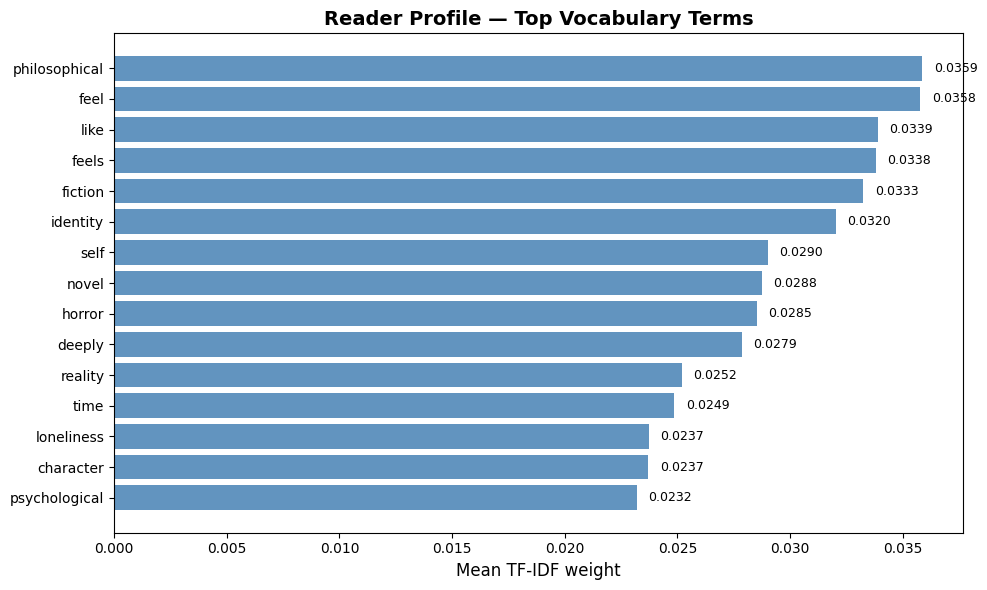

In [30]:
top_n        = 15
mean_weights = tfidf_array.mean(axis=0)
top_idx      = mean_weights.argsort()[::-1][:top_n]
top_words    = [feature_names[i] for i in top_idx]
top_scores   = [mean_weights[i]  for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_words[::-1], top_scores[::-1], color='steelblue', alpha=0.85)
ax.set_xlabel('Mean TF-IDF weight', fontsize=12)
ax.set_title('Reader Profile — Top Vocabulary Terms', fontsize=14, fontweight='bold')

for bar, score in zip(ax.patches, top_scores[::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(DRIVE_PATH, 'reader_profile_tfidf.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

logger.info("Profile chart saved to: %s", plot_path)


**Incremental processing / Procesamiento incremental:**  
The `processed` flag in `user_notes.csv` is now updated.  
The next run will only compute BERT embeddings for notes added after this point,  
and will load already-cleaned text directly from `user_notes_processed.csv`.

*El flag `processed` en `user_notes.csv` ha sido actualizado.  
La próxima ejecución solo calculará embeddings BERT para las notas añadidas después de este punto,  
y cargará el texto ya limpio directamente desde `user_notes_processed.csv`.*